### Ensembles
Here we will try to build an ensemble of models and data approaches.

In [1]:
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
from plots import plot_metrics
import pandas as pd
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.cross_decomposition import PLSRegression
import torch
from scipy.signal import savgol_filter
from autogluon.tabular import TabularPredictor
from skimage.filters import threshold_otsu
import matplotlib.pyplot as plt

In [2]:
s = pd.read_csv('data/raw/Poland_spc.csv')
wavelengths = s.columns[1:].values.astype(float)

data = np.load("data/dataset_splits.npz")

data_proccesed = np.load("data/predictions/snv_sg1_preprocessed_spectra.npz")

X_train_raw = data['X_train']
X_test_raw = data['X_test']

X_train_processed = data_proccesed["X_train_pp"]
X_test_processed = data_proccesed["X_test_pp"]

y_train = data["y_train"]
y_test = data["y_test"]

y_train_log = np.log1p(data["y_train"])
y_test_log = np.log1p(data["y_test"])

In [3]:
# Here we tuned predictors to use in the ensemble
model_files = {
#    "SVR":             "data/predictions/svr_snv_sg1_preds.npz",
    "AutoGluon":       "data/predictions/gluon_snv_sg1_preds.npz",
    "AutoGluon_logY":  "data/predictions/gluon_snv_sg1_y_log_preds.npz",
    "FCN":             "data/predictions/fcn_snv_sg1_preds.npz",
#    "PLSR":            "data/predictions/pslr_snv_sg1_preds.npz",
    "PLSR_AUC_split":  "data/predictions/pslr_auc_split_preds.npz",
}

train_preds, test_preds = {}, {}
for name, path in model_files.items():
    d = np.load(path)
    train_preds[name] = d["pred_train"].ravel()
    test_preds[name] = d["pred_test"].ravel()
    print(f"{name:20s}  train: {train_preds[name].shape}  test: {test_preds[name].shape}")


model_names = list(train_preds.keys())
X_meta_train = np.column_stack([train_preds[n] for n in model_names])
X_meta_test = np.column_stack([test_preds[n] for n in model_names])
print(f"\nMeta features: {X_meta_train.shape[1]} models")
print(f"X_meta_train: {X_meta_train.shape}, X_meta_test: {X_meta_test.shape}")

AutoGluon             train: (1254,)  test: (314,)
AutoGluon_logY        train: (1254,)  test: (314,)
FCN                   train: (1254,)  test: (314,)
PLSR_AUC_split        train: (1254,)  test: (314,)

Meta features: 4 models
X_meta_train: (1254, 4), X_meta_test: (314, 4)


In [4]:
# Train stacking meta-learner
y_train_flat = y_train.ravel()
y_test_flat = y_test.ravel()

# RidgeCV with 10-fold CV
ridge = RidgeCV(alphas=np.logspace(-4, 4, 50), cv=10)
ridge.fit(X_meta_train, y_train_flat)
print(f"RidgeCV best alpha: {ridge.alpha_:.4f}")
print(f"Ridge coefficients: {dict(zip(model_names, ridge.coef_.round(3)))}")
print(f"Ridge intercept:    {ridge.intercept_:.3f}")

y_pred_ridge_train = ridge.predict(X_meta_train)
y_pred_ridge_test = ridge.predict(X_meta_test)

# Simple mean baseline
y_pred_mean_train = X_meta_train.mean(axis=1)
y_pred_mean_test = X_meta_test.mean(axis=1)


results = []
for name, y_pred in [("Ridge Ensemble", y_pred_ridge_test), ("Mean Ensemble", y_pred_mean_test)]:
    r2 = r2_score(y_test_flat, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_flat, y_pred))
    rpd = np.std(y_test_flat) / rmse
    results.append((name, r2, rmse, rpd))

# Individual model results for comparison
for name in model_names:
    y_pred = test_preds[name]
    r2 = r2_score(y_test_flat, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_flat, y_pred))
    rpd = np.std(y_test_flat) / rmse
    results.append((name, r2, rmse, rpd))

print(f"\n{'Model':<20s}  {'R²':>6s}  {'RMSE':>7s}  {'RPD':>5s}")
print("-" * 45)
for name, r2, rmse, rpd in sorted(results, key=lambda x: -x[1]):
    print(f"{name:<20s}  {r2:6.3f}  {rmse:7.3f}  {rpd:5.2f}")

RidgeCV best alpha: 1048.1131
Ridge coefficients: {'AutoGluon': 0.745, 'AutoGluon_logY': 0.111, 'FCN': 0.154, 'PLSR_AUC_split': 0.025}
Ridge intercept:    -0.590

Model                     R²     RMSE    RPD
---------------------------------------------
Ridge Ensemble         0.864    5.715   2.71
Mean Ensemble          0.863    5.731   2.70
AutoGluon              0.853    5.938   2.61
FCN                    0.819    6.592   2.35
AutoGluon_logY         0.806    6.812   2.27
PLSR_AUC_split         0.788    7.123   2.17


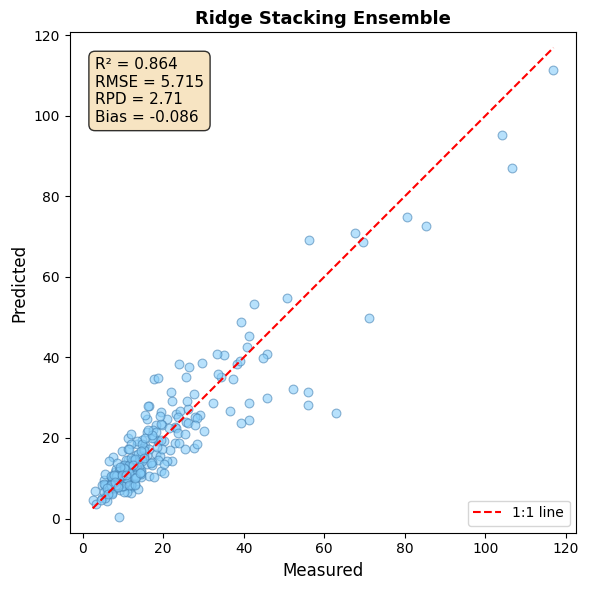

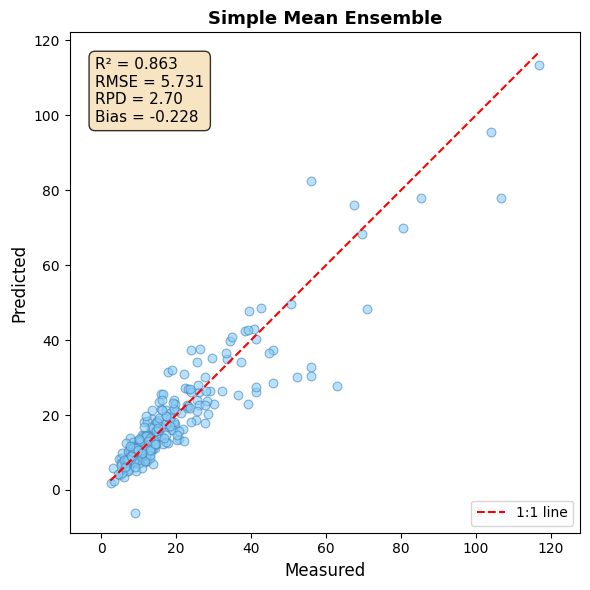

In [5]:
# Evaluate and plot
plot_metrics(y_test_flat, y_pred_ridge_test, "Ridge Stacking Ensemble")
plot_metrics(y_test_flat, y_pred_mean_test, "Simple Mean Ensemble")

### Global evaluation
To try answer the question about global tranferability, let us check how Poland-data trained model will work on data from other countries:

In [61]:
import os, glob, joblib

countries_dir = "data/all_countries"
all_X, all_y, all_countries = [], [], []

for folder in sorted(os.listdir(countries_dir)):
    folder_path = os.path.join(countries_dir, folder)
    if not os.path.isdir(folder_path):
        continue
    lab_files = glob.glob(os.path.join(folder_path, "*_lab.csv"))
    spc_files = glob.glob(os.path.join(folder_path, "*_spc.csv"))
    if not lab_files or not spc_files:
        continue
    lab = pd.read_csv(lab_files[0])
    spc = pd.read_csv(spc_files[0])
    # Drop organic soils
    mineral_mask = lab['MINERAL'] != 'organic'
    lab = lab[mineral_mask]
    spc = spc[mineral_mask]
    X = spc.iloc[:, 1:].values.astype(float)  # drop index column, ensure numeric
    y = lab['SOC'].values
    country = lab['COUNTRY'].values[0] if 'COUNTRY' in lab.columns else folder
    all_X.append(X)
    all_y.append(y)
    all_countries.append(np.full(len(y), country))
    print(f"{country:30s}  n={len(y):5d}  (dropped {(~mineral_mask).sum()} organic)")

X_countries = np.vstack(all_X)
y_countries = np.concatenate(all_y)
countries_labels = np.concatenate(all_countries)
print(f"\nTotal: {len(y_countries)} samples from {len(np.unique(countries_labels))} countries")

AUSTRIA                         n= 1475  (dropped 54 organic)
LITHUANIA                       n=  800  (dropped 123 organic)
FINLAND                         n= 1163  (dropped 502 organic)
FRANCE                          n= 2763  (dropped 44 organic)
GERMANY                         n= 1747  (dropped 72 organic)
ITALY                           n= 1164  (dropped 16 organic)
SPAIN                           n= 2577  (dropped 27 organic)
SWEDEN                          n= 1558  (dropped 675 organic)
UNITED KINGDOM                  n=  937  (dropped 152 organic)

Total: 14184 samples from 9 countries


/tmp/ipykernel_62055/257292388.py:15: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  spc = pd.read_csv(spc_files[0])


A dirty copy-paste of low/high AUC model from the pslr notebook to predict on the global data:

In [62]:
s = pd.read_csv('data/raw/Poland_spc.csv')
wavelengths = s.columns[1:].values.astype(float)

data = np.load("data/dataset_splits.npz")

data_proccesed = np.load("data/predictions/snv_sg1_preprocessed_spectra.npz")

X_train_raw = data['X_train']
X_test_raw = data['X_test']

X_train_processed = data_proccesed["X_train_pp"]
X_test_processed = data_proccesed["X_test_pp"]

y_train = data["y_train"]
y_test = data["y_test"]

y_train_log = np.log1p(data["y_train"])
y_test_log = np.log1p(data["y_test"])


wavelengths = s.columns[1:].values.astype(float)

# Area under the reflectance curve for each sample
auc_train = np.trapz(X_train_raw, wavelengths, axis=1)
auc_test  = np.trapz(X_test_raw,  wavelengths, axis=1)

# Otsu threshold on training AUC
auc_threshold = threshold_otsu(auc_train) - 200 # Adjusted threshold to create a more balanced split

mask_train_low  = auc_train <= auc_threshold
mask_train_high = auc_train >  auc_threshold
mask_test_low   = auc_test  <= auc_threshold
mask_test_high  = auc_test  >  auc_threshold

print(f"AUC threshold: {auc_threshold:.4f}")
print(f"Train — Learner A (low):  {mask_train_low.sum():4d}  Learner B (high): {mask_train_high.sum()}")
print(f"Test  — Learner A (low):  {mask_test_low.sum():4d}  Learner B (high): {mask_test_high.sum()}")

X_train_low,  y_train_low  = X_train_raw[mask_train_low],  y_train[mask_train_low]
X_train_high, y_train_high = X_train_raw[mask_train_high], y_train[mask_train_high]
X_test_low,   y_test_low   = X_test_raw[mask_test_low],    y_test[mask_test_low]
X_test_high,  y_test_high  = X_test_raw[mask_test_high],   y_test[mask_test_high]

X_train_proc_low,  y_train_proc_low  = X_train_processed[mask_train_low],  y_train[mask_train_low]
X_train_proc_high, y_train_proc_high = X_train_processed[mask_train_high], y_train[mask_train_high]
X_test_proc_low,   y_test_proc_low   = X_test_processed[mask_test_low],    y_test[mask_test_low]
X_test_proc_high,  y_test_proc_high  = X_test_processed[mask_test_high],   y_test[mask_test_high]


max_comps = 60
cv = KFold(n_splits=10, shuffle=True, random_state=42)

pipe = Pipeline([("pls", PLSRegression())])
param_grid = {"pls__n_components": range(1, max_comps + 1)}

grid_proc_x_y_low = GridSearchCV(pipe, param_grid, cv=cv, scoring="r2", n_jobs=-1, verbose=1)
grid_proc_x_y_low.fit(X_train_proc_low, y_train_proc_low)

grid_proc_x_y_high = GridSearchCV(pipe, param_grid, cv=cv, scoring="r2", n_jobs=-1, verbose=1)
grid_proc_x_y_high.fit(X_train_proc_high, y_train_proc_high)


AUC threshold: 512.8204
Train — Learner A (low):    84  Learner B (high): 1170
Test  — Learner A (low):    20  Learner B (high): 294
Fitting 10 folds for each of 60 candidates, totalling 600 fits
Fitting 10 folds for each of 60 candidates, totalling 600 fits


,estimator,Pipeline(step...egression())])
,param_grid,"{'pls__n_components': range(1, 61)}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_components,26


In [49]:

def snv(X, eps=1e-12):
    mu = X.mean(axis=1, keepdims=True)
    sd = X.std(axis=1, keepdims=True)
    return (X - mu) / (sd + eps)

def sg_first_derivative(X, window_length=11, polyorder=2):
    return savgol_filter(X, window_length=window_length, polyorder=polyorder, deriv=1, axis=1)

def preprocess(X):
    return sg_first_derivative(snv(X), window_length=11, polyorder=2)

X_countries_pp = preprocess(X_countries)

# --- AutoGluon predictions ---
col_names = [f"{i}" for i in range(X_countries_pp.shape[1])]

ag_model = TabularPredictor.load("AutogluonModels/ag-20260301_094157")
ag_preds = ag_model.predict(pd.DataFrame(X_countries_pp, columns=col_names)).values

ag_log_model = TabularPredictor.load("AutogluonModels/ag-20260301_095650")
ag_log_preds = np.expm1(ag_log_model.predict(pd.DataFrame(X_countries_pp, columns=col_names)).values)

# --- FCN predictions ---
fcn_scaler = joblib.load("data/predictions/fcn_scaler_pp.pkl")
X_countries_pp_scaled = fcn_scaler.transform(X_countries_pp).astype(np.float32)

class FCN(torch.nn.Module):
    def __init__(self, input_dim=1000, layers=(512, 256, 128), dropout=0.2):
        super().__init__()
        modules = []
        in_features = input_dim
        for out_features in layers:
            modules.append(torch.nn.Linear(in_features, out_features))
            modules.append(torch.nn.BatchNorm1d(out_features))
            modules.append(torch.nn.ReLU())
            modules.append(torch.nn.Dropout(dropout))
            in_features = out_features
        modules.pop()
        modules.append(torch.nn.Linear(in_features, 1))
        self.net = torch.nn.Sequential(*modules)
    def forward(self, x):
        return self.net(x).squeeze(-1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
fcn_model = FCN().to(device)
fcn_model.load_state_dict(torch.load("data/predictions/fcn_model_pp.pt", map_location=device))
fcn_model.eval()

with torch.no_grad():
    fcn_preds = fcn_model(torch.from_numpy(X_countries_pp_scaled).to(device)).cpu().numpy()

# --- PLSR AUC-split predictions ---
auc_countries = np.trapz(X_countries, wavelengths, axis=1)
mask_low = auc_countries <= auc_threshold
mask_high = auc_countries > auc_threshold

plsr_auc_preds = np.empty(len(y_countries))
plsr_auc_preds[mask_low] = grid_proc_x_y_low.best_estimator_.predict(X_countries_pp[mask_low]).ravel()
plsr_auc_preds[mask_high] = grid_proc_x_y_high.best_estimator_.predict(X_countries_pp[mask_high]).ravel()

print(f"AUC split: {mask_low.sum()} low, {mask_high.sum()} high")
print(f"All prediction shapes: AG={ag_preds.shape}, AG_log={ag_log_preds.shape}, FCN={fcn_preds.shape}, PLSR_AUC={plsr_auc_preds.shape}")

AUC split: 360 low, 13824 high
All prediction shapes: AG=(14184,), AG_log=(14184,), FCN=(14184,), PLSR_AUC=(14184,)


In [63]:
# Stack and predict with Ridge ensemble
X_meta_countries = np.column_stack([ag_preds, ag_log_preds, fcn_preds, plsr_auc_preds])
y_pred_ensemble = ridge.predict(X_meta_countries)

# Also compute mean ensemble
y_pred_mean = X_meta_countries.mean(axis=1)

Model                     R²     RMSE    RPD
---------------------------------------------
AutoGluon              0.364   15.772   1.25
AutoGluon_logY         0.296   16.582   1.19
Ridge Ensemble         0.257   17.044   1.16
Mean Ensemble         -0.499   24.206   0.82
FCN                   -0.568   24.756   0.80
PLSR_AUC_split        -6.169   52.932   0.37


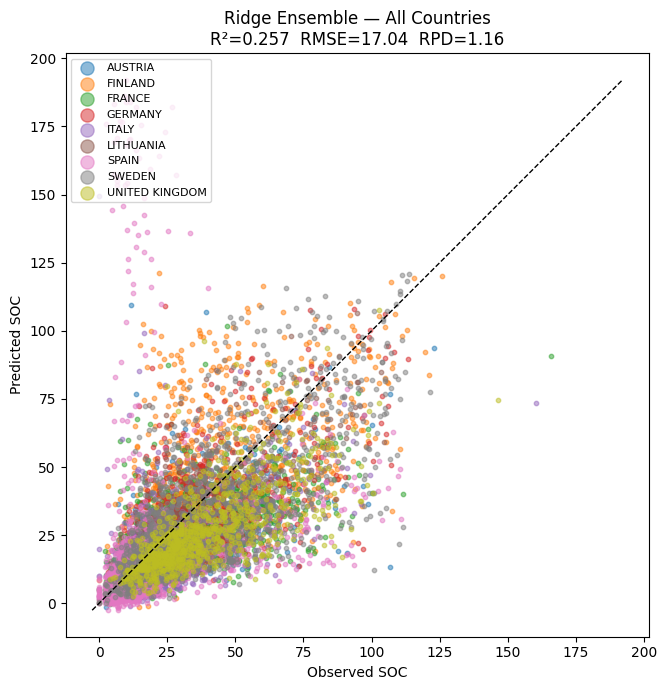

In [53]:
# Overall metrics table
results = []
for name, preds in [("Ridge Ensemble", y_pred_ensemble), ("Mean Ensemble", y_pred_mean),
                     ("AutoGluon", ag_preds), ("AutoGluon_logY", ag_log_preds),
                     ("FCN", fcn_preds), ("PLSR_AUC_split", plsr_auc_preds)]:
    r2 = r2_score(y_countries, preds)
    rmse = np.sqrt(mean_squared_error(y_countries, preds))
    rpd = np.std(y_countries) / rmse
    results.append((name, r2, rmse, rpd))

print(f"{'Model':<20s}  {'R²':>6s}  {'RMSE':>7s}  {'RPD':>5s}")
print("-" * 45)
for name, r2, rmse, rpd in sorted(results, key=lambda x: -x[1]):
    print(f"{name:<20s}  {r2:6.3f}  {rmse:7.3f}  {rpd:5.2f}")

# Overall predicted vs observed colored by country
r2 = r2_score(y_countries, y_pred_ensemble)
rmse = np.sqrt(mean_squared_error(y_countries, y_pred_ensemble))
rpd = np.std(y_countries) / rmse

fig, ax = plt.subplots(figsize=(8, 7))
for country in np.unique(countries_labels):
    mask = countries_labels == country
    ax.scatter(y_countries[mask], y_pred_ensemble[mask], alpha=0.5, s=10, label=country)

lo = min(y_countries.min(), y_pred_ensemble.min())
hi = max(y_countries.max(), y_pred_ensemble.max())
ax.plot([lo, hi], [lo, hi], 'k--', lw=1)
ax.set_xlabel("Observed SOC")
ax.set_ylabel("Predicted SOC")
ax.set_title(f"Ridge Ensemble — All Countries\nR²={r2:.3f}  RMSE={rmse:.2f}  RPD={rpd:.2f}")
ax.legend(markerscale=3, fontsize=8, loc='upper left')
ax.set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

In [54]:
# Per-country metrics table
unique_countries = np.unique(countries_labels)
print(f"{'Country':<35s}  {'n':>5s}  {'R²':>6s}  {'RMSE':>7s}  {'RPD':>5s}")
print("-" * 65)
for country in unique_countries:
    mask = countries_labels == country
    r2 = r2_score(y_countries[mask], y_pred_ensemble[mask])
    rmse = np.sqrt(mean_squared_error(y_countries[mask], y_pred_ensemble[mask]))
    rpd = np.std(y_countries[mask]) / rmse
    print(f"{country:<35s}  {mask.sum():5d}  {r2:6.3f}  {rmse:7.3f}  {rpd:5.2f}")

Country                                  n      R²     RMSE    RPD
-----------------------------------------------------------------
AUSTRIA                               1475   0.410   11.590   1.30
FINLAND                               1163   0.180   21.579   1.10
FRANCE                                2763   0.350   12.790   1.24
GERMANY                               1747   0.504   12.153   1.42
ITALY                                 1164   0.096   13.739   1.05
LITHUANIA                              800   0.731    9.219   1.93
SPAIN                                 2577  -1.199   24.385   0.67
SWEDEN                                1558   0.416   18.777   1.31
UNITED KINGDOM                         937   0.141   17.927   1.08


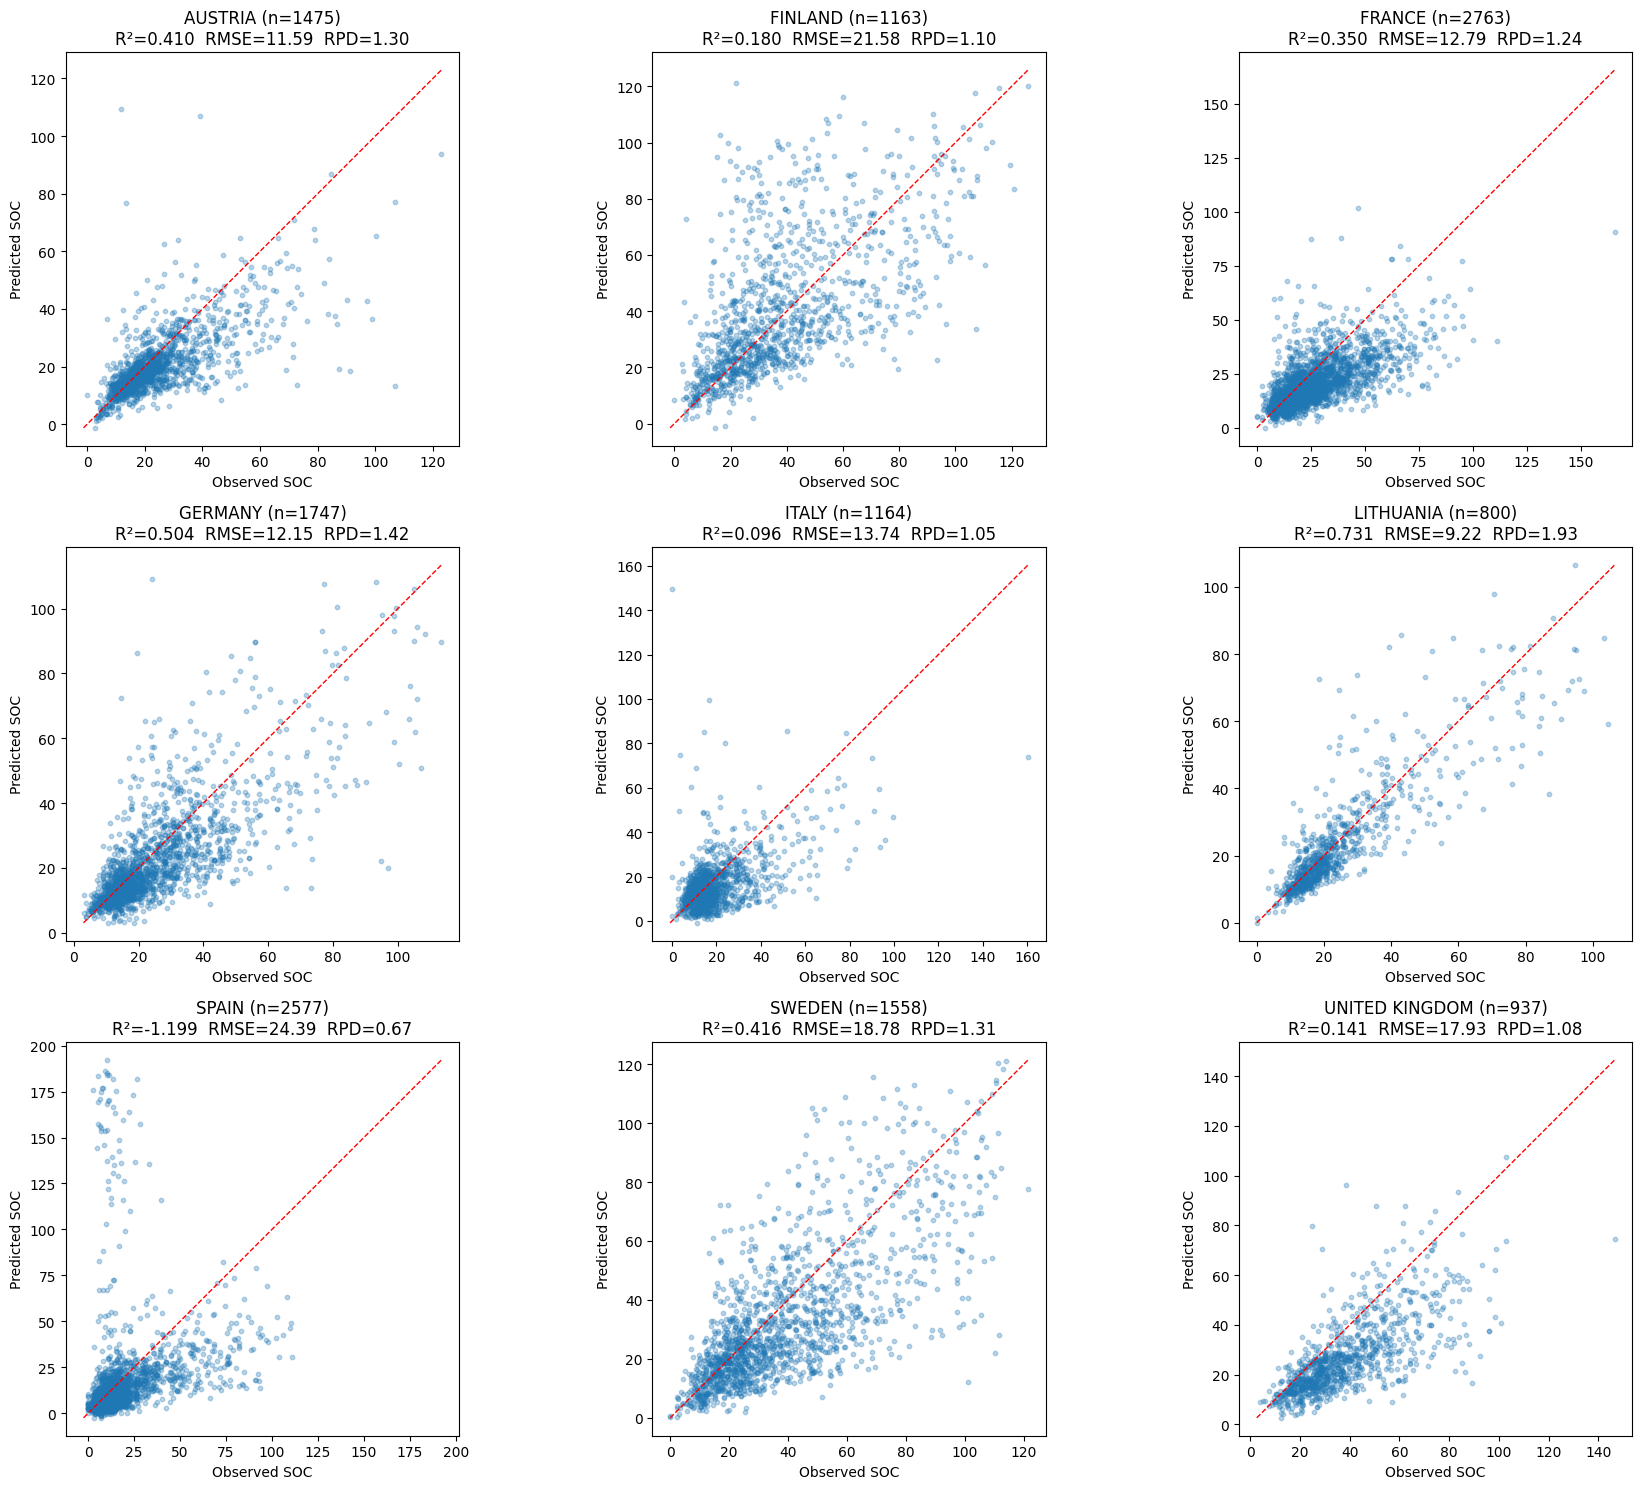

In [55]:
# Per-country predicted vs observed plots
n_countries = len(unique_countries)
ncols = 3
nrows = (n_countries + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
axes = axes.flatten()

for i, country in enumerate(unique_countries):
    ax = axes[i]
    mask = countries_labels == country
    y_true = y_countries[mask]
    y_pred = y_pred_ensemble[mask]
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    rpd = np.std(y_true) / rmse

    ax.scatter(y_true, y_pred, alpha=0.3, s=10)
    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1)
    ax.set_xlabel("Observed SOC")
    ax.set_ylabel("Predicted SOC")
    ax.set_title(f"{country} (n={mask.sum()})\nR²={r2:.3f}  RMSE={rmse:.2f}  RPD={rpd:.2f}")
    ax.set_aspect('equal', adjustable='box')

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

AutoGluon — All Countries
R²=0.364  RMSE=15.772  RPD=1.25  n=14184


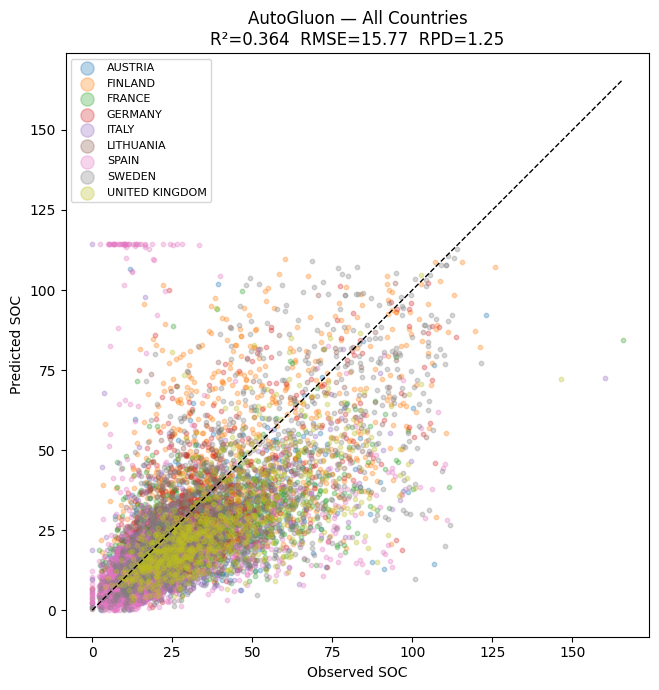

In [56]:
# AutoGluon — overall metrics + colored scatter
r2 = r2_score(y_countries, ag_preds)
rmse = np.sqrt(mean_squared_error(y_countries, ag_preds))
rpd = np.std(y_countries) / rmse
print(f"AutoGluon — All Countries")
print(f"R²={r2:.3f}  RMSE={rmse:.3f}  RPD={rpd:.2f}  n={len(y_countries)}")

fig, ax = plt.subplots(figsize=(8, 7))
for country in unique_countries:
    mask = countries_labels == country
    ax.scatter(y_countries[mask], ag_preds[mask], alpha=0.3, s=10, label=country)

lo = min(y_countries.min(), ag_preds.min())
hi = max(y_countries.max(), ag_preds.max())
ax.plot([lo, hi], [lo, hi], 'k--', lw=1)
ax.set_xlabel("Observed SOC")
ax.set_ylabel("Predicted SOC")
ax.set_title(f"AutoGluon — All Countries\nR²={r2:.3f}  RMSE={rmse:.2f}  RPD={rpd:.2f}")
ax.legend(markerscale=3, fontsize=8, loc='upper left')
ax.set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

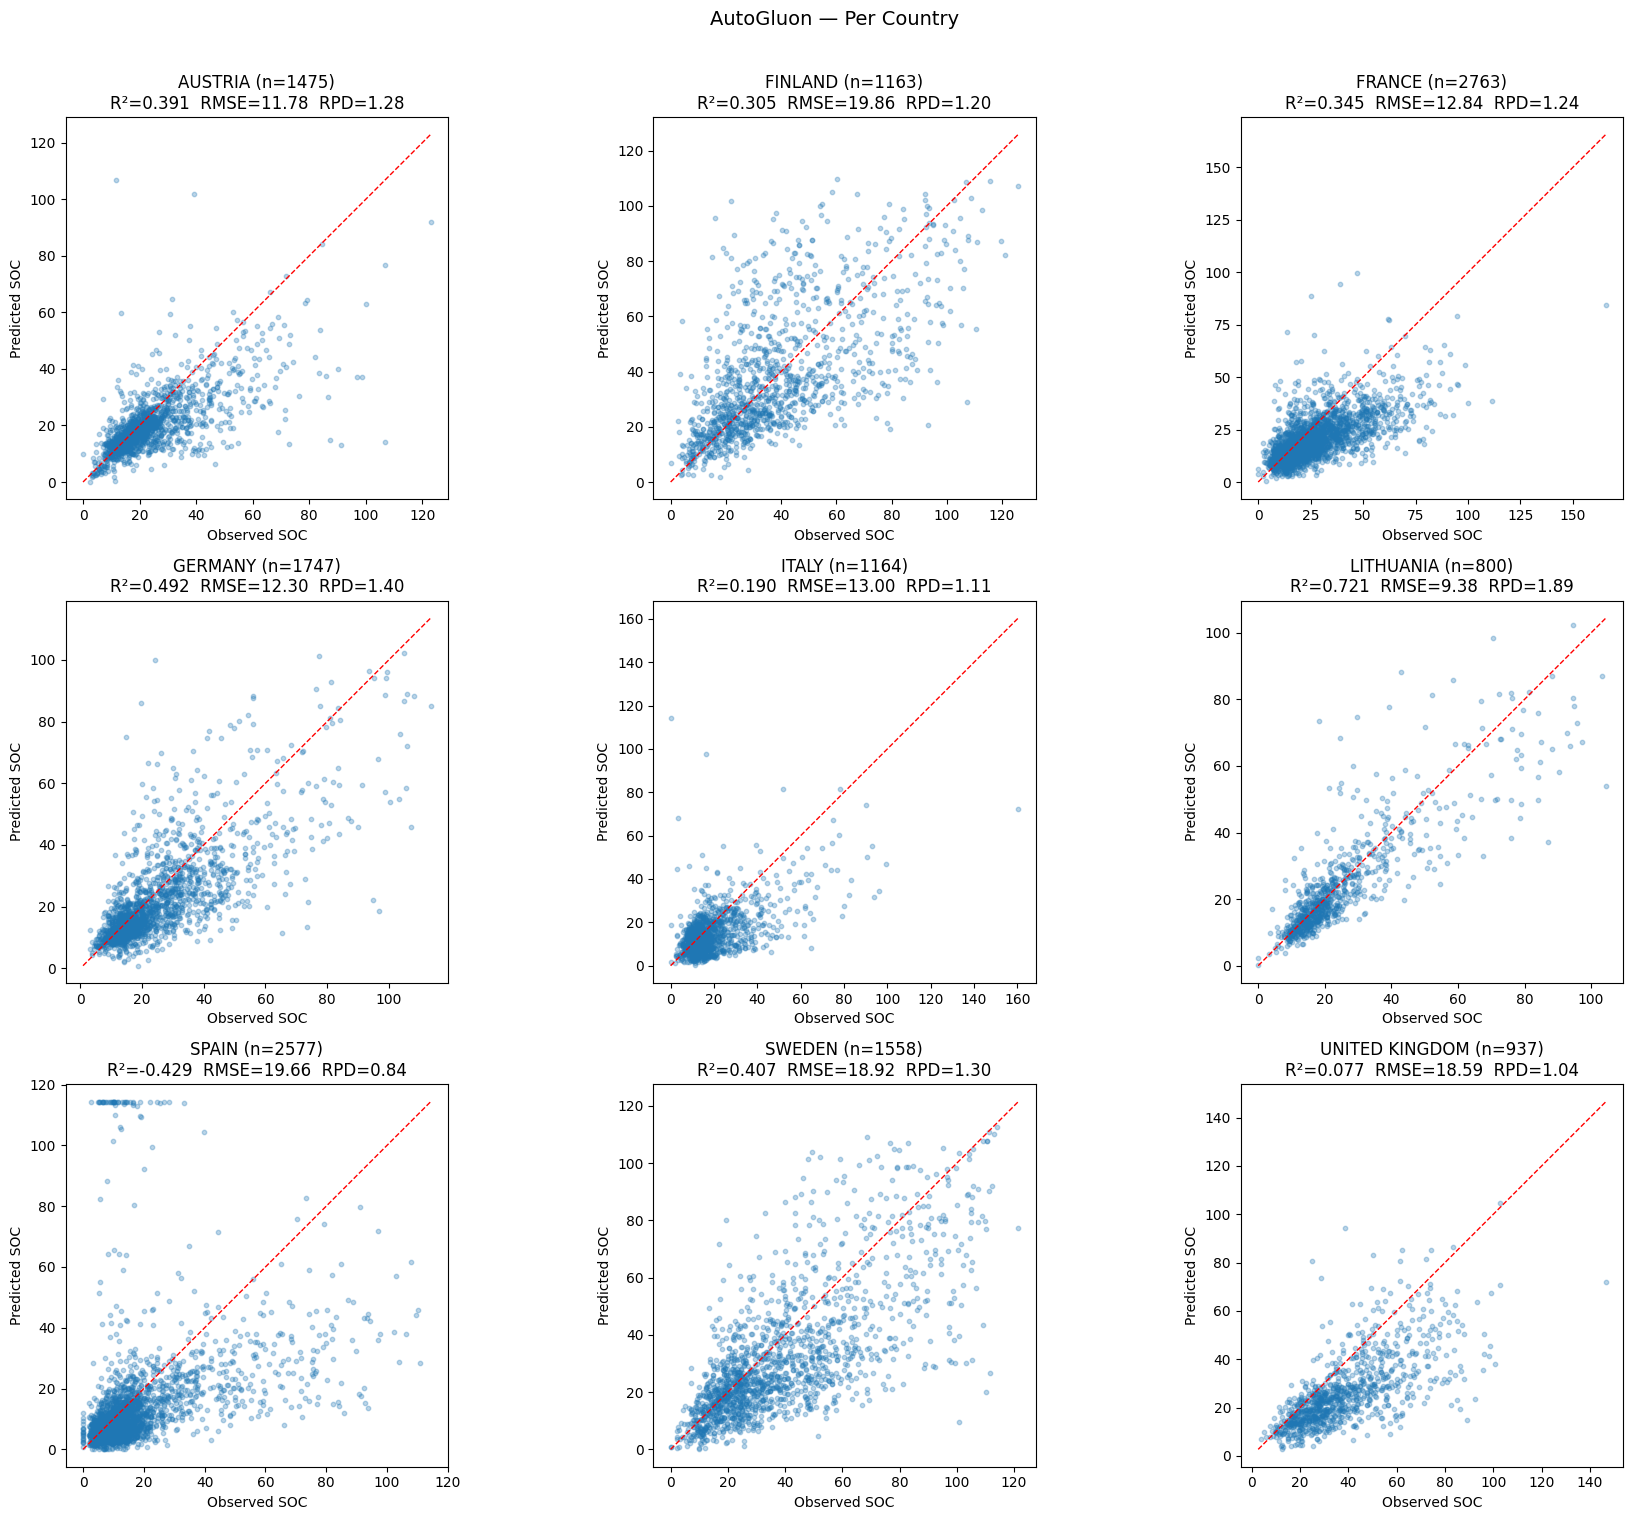

In [57]:
# AutoGluon — per-country predicted vs observed
n_countries = len(unique_countries)
ncols = 3
nrows = (n_countries + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
axes = axes.flatten()

for i, country in enumerate(unique_countries):
    ax = axes[i]
    mask = countries_labels == country
    y_true = y_countries[mask]
    y_pred = ag_preds[mask]
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    rpd = np.std(y_true) / rmse

    ax.scatter(y_true, y_pred, alpha=0.3, s=10)
    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1)
    ax.set_xlabel("Observed SOC")
    ax.set_ylabel("Predicted SOC")
    ax.set_title(f"{country} (n={mask.sum()})\nR²={r2:.3f}  RMSE={rmse:.2f}  RPD={rpd:.2f}")
    ax.set_aspect('equal', adjustable='box')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("AutoGluon — Per Country", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()